  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


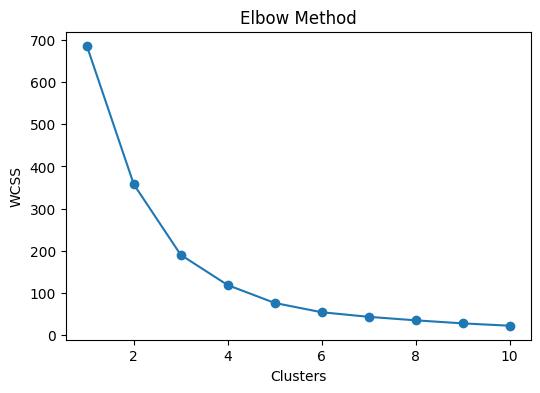

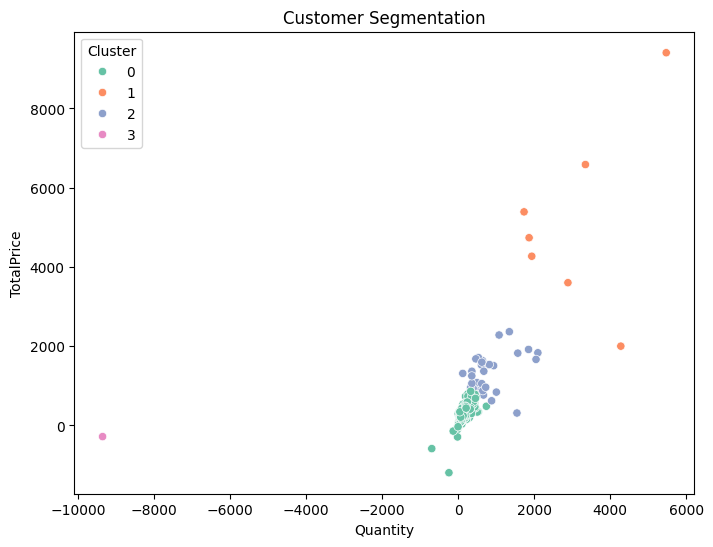

           CustomerID     Quantity   TotalPrice
Cluster                                        
0        15522.374172   129.291391   254.530166
1        16151.714286  3075.142857  5142.841429
2        14742.545455   811.818182  1303.726061
3        15838.000000 -9360.000000  -280.800000
Task 2 Completed Successfully!


In [2]:
# ================================
# Customer Segmentation - Task 2
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset
df = pd.read_csv('/content/online_retail.csv', encoding='ISO-8859-1')

# Display Dataset
print(df.head())

# Remove Missing Customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove Duplicates
df = df.drop_duplicates()

# Create Total Price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Customer-wise Data
customer_data = df.groupby('CustomerID').agg({
    'Quantity':'sum',
    'TotalPrice':'sum'
}).reset_index()

# Feature Selection
X = customer_data[['Quantity','TotalPrice']]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customer_data,
    x='Quantity',
    y='TotalPrice',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segmentation")
plt.show()

# Cluster Summary
print(customer_data.groupby('Cluster').mean())

# Save Output
customer_data.to_csv("Customer_Segmentation_Output.csv", index=False)

print("Task 2 Completed Successfully!")